# Домашнее задание по теме «Табличные данные и визуализация»

В этом задании ты изучишь датасет Student Depression. Надеемся, что выводы, которые ты сделаешь после анализа датасета, пригодятся в реальной жизни!

Обрати внимание, что около каждой задачи указано количество баллов, которое можно получить за её выполнение.



> ### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
 > 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
> 6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.


## Установка библиотек

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as sps
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

plt.style.use("ggplot")

## Задание 1 [1 балл]

Необходимые данные хранятся по [ссылке](https://drive.google.com/file/d/1WdZxvQQQH9MGTOH2yIjjewd0KuEsrZvl/view?usp=drive_link). Загрузи их в ноутбук.

1. Воспользуйся командой `gdown` для загрузки данных **[0 баллов]**.
2. Считай датасет в pandas dataframe **[0,2 балла]**.
3. Выведи датасет на экран **[0,3 балла]**.
4. Исключи переменную `id` или сделай её индексом. Можешь выбрать любой вариант **[0,5 балла]**.

In [2]:
# 1. Загрузи файл
import gdown
gdown.download(id="1NiF28k5POrZsofchU6k0X1AR3OCVJl4s")

Downloading...
From: https://drive.google.com/uc?id=1NiF28k5POrZsofchU6k0X1AR3OCVJl4s
To: C:\ai-intro\homeworks\homework_1\Student Depression Dataset.csv
100%|██████████| 2.81M/2.81M [00:00<00:00, 4.56MB/s]


'Student Depression Dataset.csv'

In [3]:
# Считай датасет
df = pd.read_csv("Student Depression Dataset.csv")

In [4]:
# Вывод датасета
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [ ]:
# Преобразуй переменную id
df = df.set_index("id")

## Задание 2 [3 балла]

Проведи первичный анализ данных.

1. Выведи информацию по типам данных каждой колонки **[0,5 балла]**.
2. Выведи информацию по NaN-значениям. Если они есть, напиши, как их можно заполнить **[0,5 балла]**.
3. Построй описательные статистики для числовых переменных (максимальное и минимальное значение, среднее) и напиши по ним выводы **[1 балл]**.
4. Сделай описательные статистики для нечисловых переменных (количество уникальных элементов, наиболее популярный представитель) **[1 балл]**.

В пунктах 3–4 тебе может помочь [документация](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html).

In [ ]:
# 1 Вывод информации о типах данных
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27901 entries, 2 to 140699
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27901 non-null  object 
 1   Age                                    27901 non-null  float64
 2   City                                   27901 non-null  object 
 3   Profession                             27901 non-null  object 
 4   Academic Pressure                      27901 non-null  float64
 5   Work Pressure                          27901 non-null  float64
 6   CGPA                                   27901 non-null  float64
 7   Study Satisfaction                     27901 non-null  float64
 8   Job Satisfaction                       27901 non-null  float64
 9   Sleep Duration                         27901 non-null  object 
 10  Dietary Habits                         27901 non-null  object 
 11  Degree

In [ ]:
# 2 Вывод информации о NaN
print(f"Кол-во NaN: {df.isna().sum().sum()}")

Кол-во NaN: 3


**Анализ NaN-значений**

Поскольку NaN-значения присутствуют только в числовом столбце, причем с диксретными значениями, а именно **целые** числа от 1 до 5, то можно дозаполнить пропуски медианой / средним или интерполировать с помощью `df.interpolate`

In [ ]:
# 3 Описательная статистика числовых переменных
df.describe().loc[["max", "min", "mean"]]

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
max,59.0000,5.000000,5.00000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000
min,18.0000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
mean,25.8223,3.141214,0.00043,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499


Напиши выводы по описательной статистике числовых переменных.



In [ ]:
# 4 Описательная статистика нечисловых переменных
df.describe(include=["O"]).loc[["unique", "top"]]

,Gender,City,Profession,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Family History of Mental Illness
unique,2,52,14,5,4,28,2,2
top,Male,Kalyan,Student,Less than 5 hours,Unhealthy,Class 12,Yes,No


Напиши выводы по описательной статистике нечисловых переменных.

## Задание 3 [4 балла]

Проведи разведочный анализ данных.

### Шаг 1 [2 балла]
Нарисуй гистограмму распределений целевой переменной `Depression` и гистограмму распределений признаков **[0,5 балла]**.

Проанализируй полученные графики **[1,5 балла]**.

Ответь на следующие вопросы как минимум для двух признаков.

1) Какое распределение у признака, и почему оно именно такое?

2) Есть ли выбросы? Чем они могут быть вызваны?

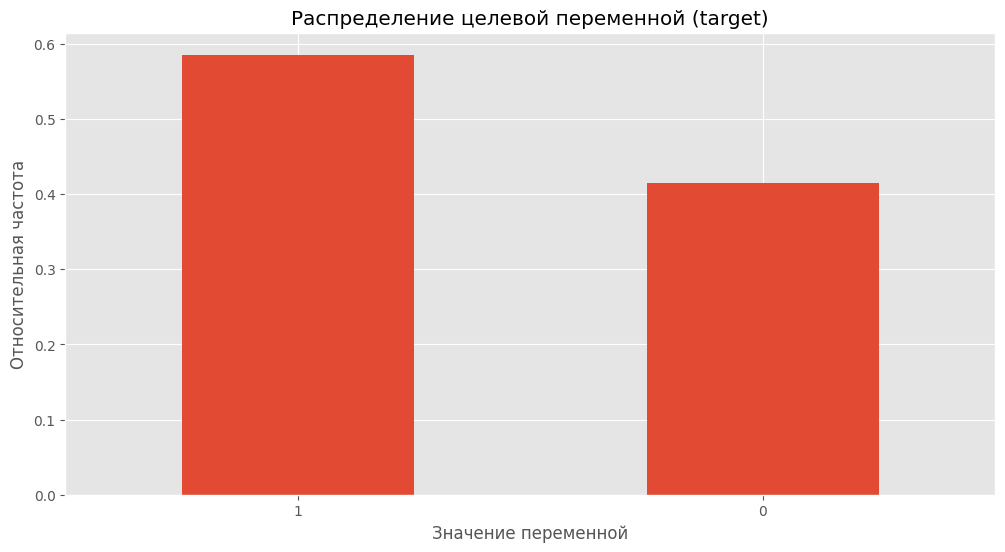

In [ ]:
plt.figure(figsize=(12, 6))
(df["Depression"].value_counts() / len(df)).plot(kind="bar", rot=0)
plt.title("Распределение целевой переменной (target)")
plt.xlabel("Значение переменной")
plt.ylabel("Относительная частота")
plt.show()

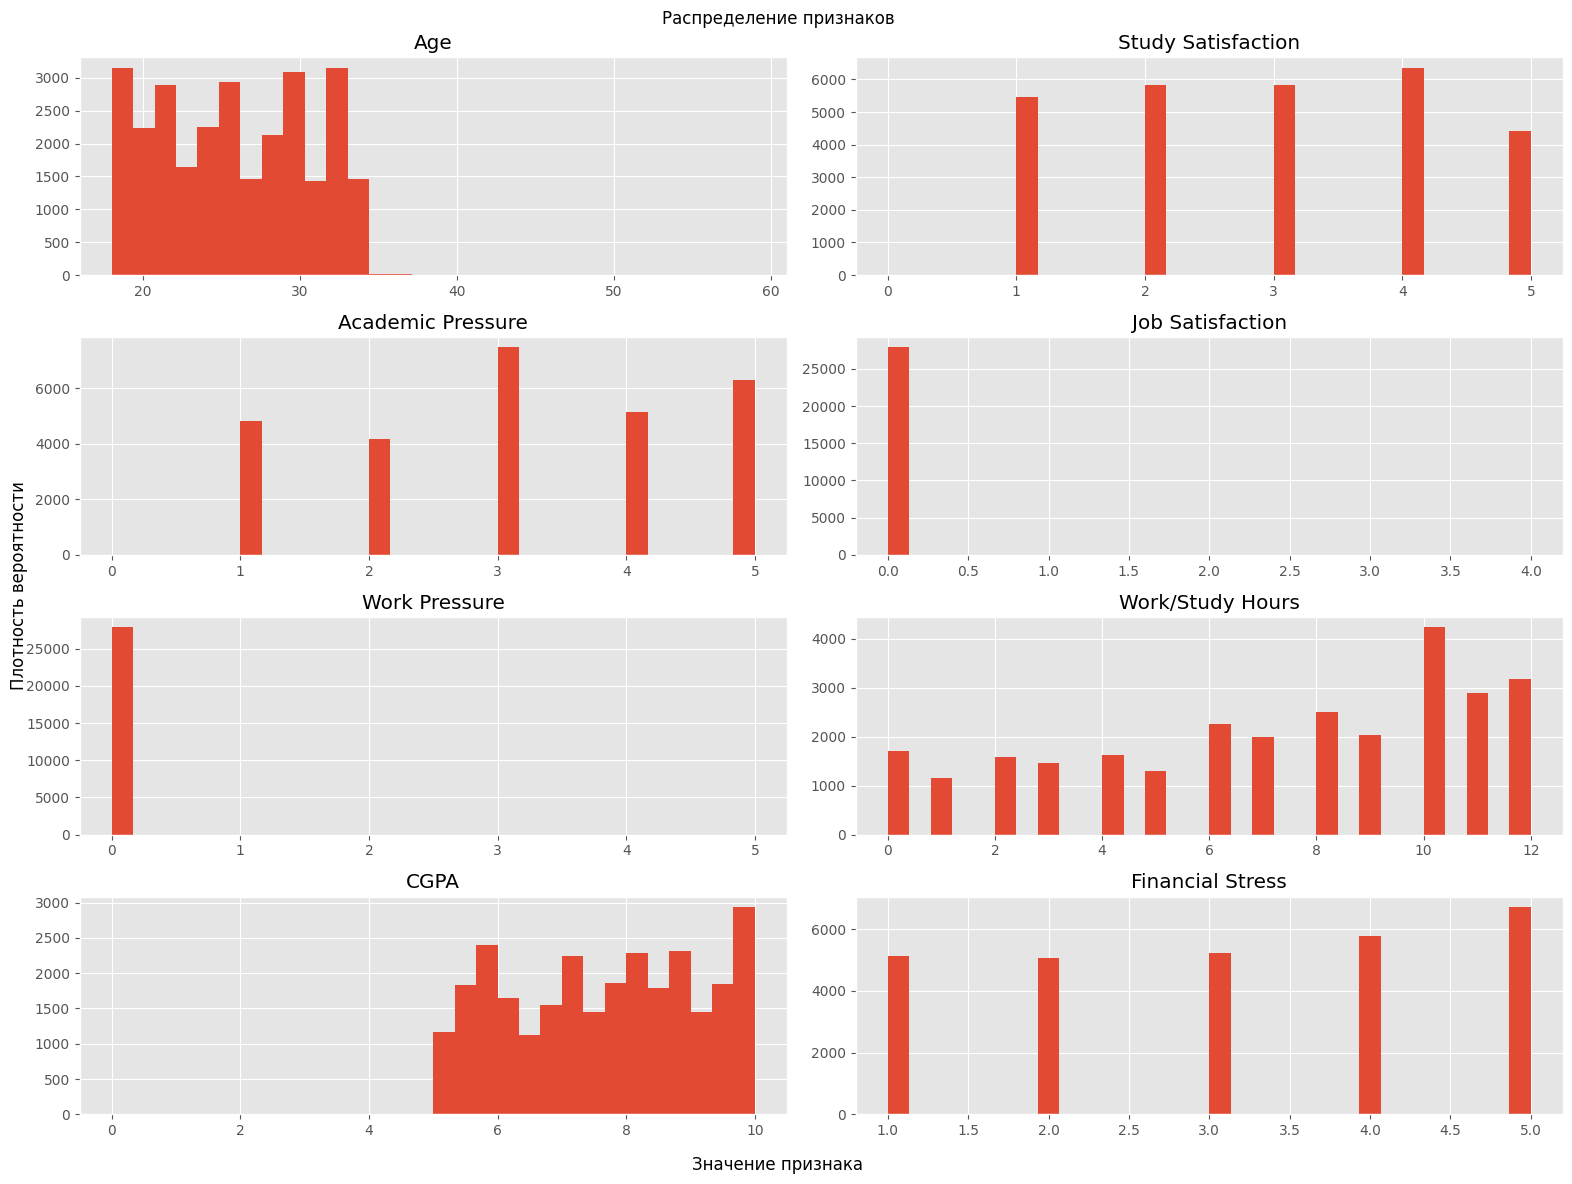

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
fig.suptitle("Распределение признаков")
fig.supxlabel("Значение признака")
fig.supylabel("Плотность вероятности")

for i, column_name in enumerate([
    "Age", "Academic Pressure", "Work Pressure",
    "CGPA", "Study Satisfaction", "Job Satisfaction",
    "Work/Study Hours", "Financial Stress"
]):
  ax = axes[i % 4, i // 4]
  ax.set_title(column_name)
  column = df[column_name]
  column.plot(kind="hist", ax=ax, bins=30)
  ax.set_ylabel("")

plt.tight_layout()
plt.show()

Проанализируй полученные графики и ответь на вопросы.



Проанализируем две, на мой взгляд, самые странные гистограммы, а именно `Job Satisfaction` и `Work Pressure`, каждая из них имеет сильные выбросы (хоть на гистограмме они и не видны, из числовой таблицы мы это видим), попробуем посмотреть на диаграмму `boxplot` для них:

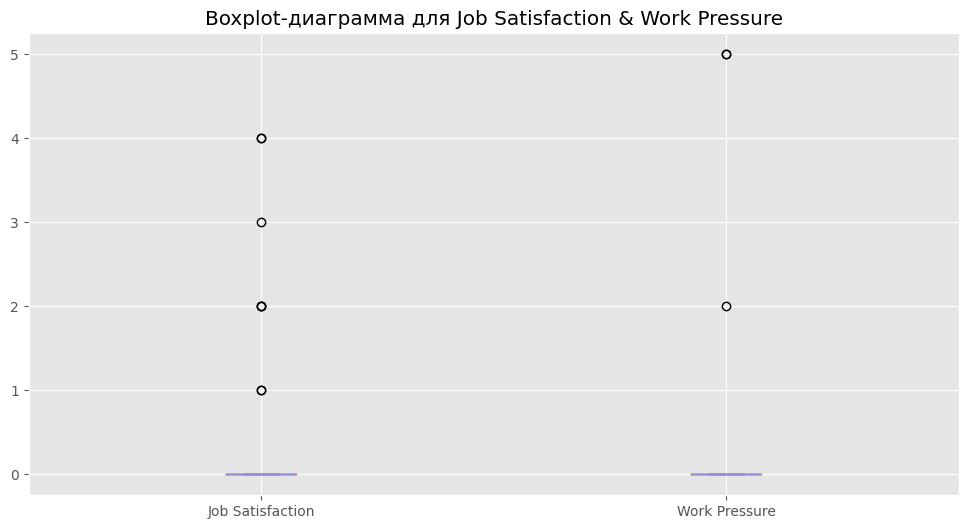

In [ ]:
df[["Job Satisfaction", "Work Pressure"]].plot(
    kind="box", figsize=(12, 6),
    title="Boxplot-диаграмма для Job Satisfaction & Work Pressure"
)
plt.show()

Выходит, что истинная ситуация такова: студенты не удовлетворены своей работой, при этом не имеют ровным счетом никакой нагрузки с ней связаной. Исключение составляют лишь несколько студентов, однако их число слишком мало, чтобы быть статистически значимым.

Исходя из этого можно сделать вывод, что практически все студенты работают там, где по факту не загружены, т.е. бесполезны, ввиду чего и падает наслаждением местом работы.

### Шаг 2 [1 балл]
 Нарисуй рядом две гистограммы.
  * Слева: гистограмма продолжительности сна.
  * Справа: гистограмма продолжительности сна, где каждая категория должна отображаться с учётом переменной `Depression`.
  * Для каждой гистограммы порядок колонок упорядочи  от минимальной продолжительности сна до максимальной. Категорию `Others` помести в начало или конец.

  Что можно сказать по полученным графикам?

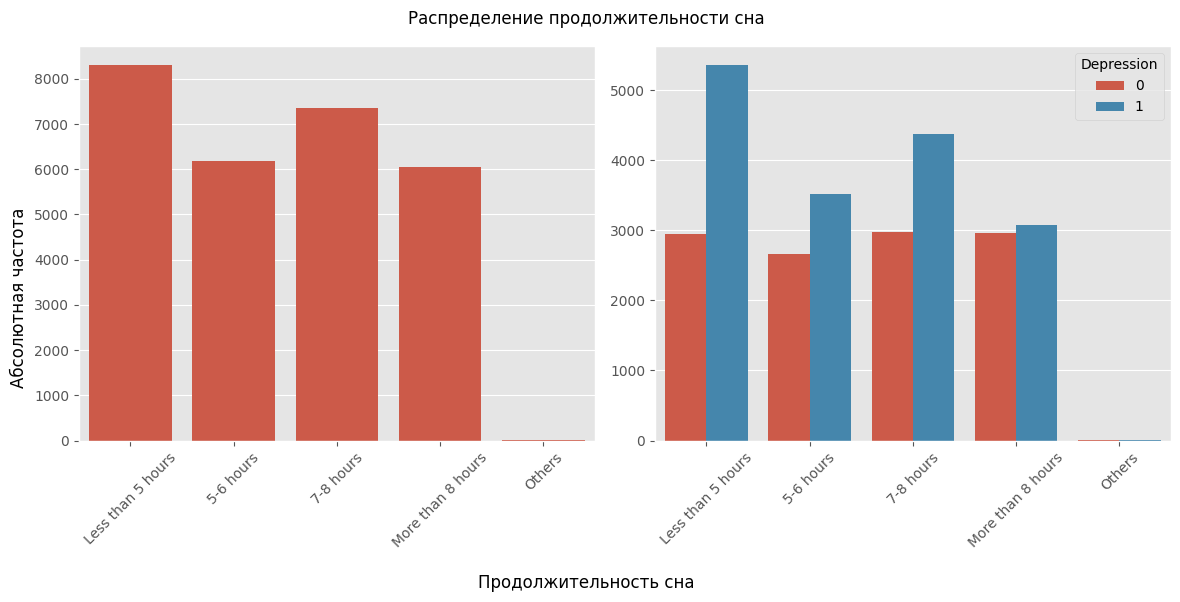

In [ ]:
df["Sleep Duration"] = pd.Categorical(
    values=df["Sleep Duration"],
    categories=["Less than 5 hours", "5-6 hours",  "7-8 hours", "More than 8 hours", "Others"],
    ordered=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Распределение продолжительности сна")
fig.supylabel("Абсолютная частота")
fig.supxlabel("Продолжительность сна")

sns.countplot(data=df, x="Sleep Duration", ax=axes[0])
axes[0].tick_params(axis='x', labelrotation=45)
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.countplot(data=df, x="Sleep Duration", hue="Depression", ax=axes[1])
axes[1].tick_params(axis='x', labelrotation=45)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Проанализируй полученные графики.



Исходя из полученных графиков видно, что наибольшая доля студентов с депрессией находится среди тех студентов, чье время сна составляет менее 5 часов.

Однако можно так же заметить, что среди тех, кто спит 5-6 часов, доля депрессии значительно ниже, но для 7-8 часов снова повышается, для тех, кто спит дольше доля депрессии наименьшая.

Таким образом, продолжительность сна напрямую влияет на наличие деперессии у студента, однако, не совсем линейно.

### Шаг 3 [1 балл]


Построй корреляционную матрицу. Выбери две самые сильные корреляции (по модулю) и попробуй объяснить возможные причины этих связей.

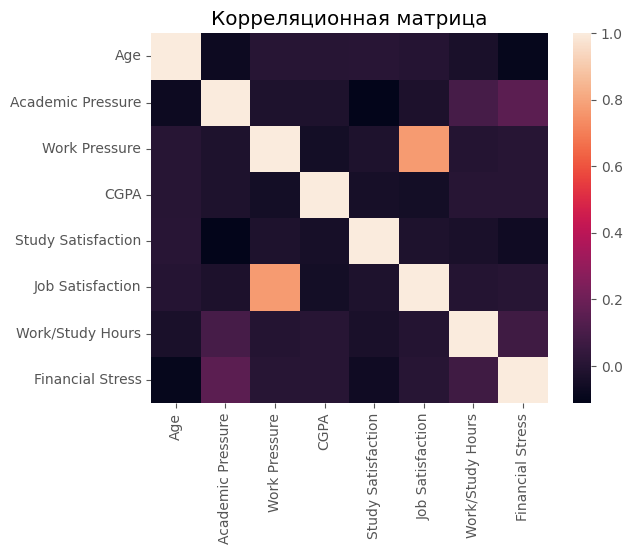

In [ ]:
ax = sns.heatmap(df[[
    "Age", "Academic Pressure", "Work Pressure",
    "CGPA", "Study Satisfaction", "Job Satisfaction",
    "Work/Study Hours", "Financial Stress"
]].corr())
ax.set_title("Корреляционная матрица")
plt.show()

Проанализируй корреляционные матрицы.

Наиболее сильные кореляции:
- Work Pressure & Job Satisfaction
- Financial Stress & Academic Pressure

Первую мы объяснили в задаче №3, но повторим еще раз, ввиду отсутствия рабочих задач студент чувствует себя бесполезным на работе, поэтому его удовлетворенность на рабочем месте близка к нулю и наоборот, чем больше задач, тем более студент видит в этом возможность самореализации, вдохновляется этим, и вместе с этим растет его наслаждение работой.

Ко второму, финансовые трудности сподвигают студентов устраиваться на подработки, ввиду нехватки времени в первую очередь страдает учеба, поэтому при увелечении рабочих часов, увеличивается и нагрзука по учебе и наоборот.



## Задание 4 [2 балла]

Выбери две модели машинного обучения. Список наиболее популярных можно посмотреть в семинаре.

- Обработай категориальные переменные **[0,5 балла]**.

- Раздели выборку на обучающую и тестовую **[0,5 балла]**.

- Обучи две модели **[0,5 балла]**.

- Измерь качество моделей по метрике Accuracy **[0,5 балла]**.

  Метрика Accuracy считает среднюю долю верных ответов и выглядит так:

$$Acc = \frac{1}{n}∑_{i=1}^nI[y_i = \hat{y_i}]\text,  \\
\text{где n — количество наблюдений;} \\
y_i \text{ — истинная метка класса для i-го наблюдения;} \\
\hat{y_i} \text{ — предсказанная метка класса для i-го наблюдения.}\\
I[y_i = \hat{y_i}] = 1, если\;y_i = \hat{y_i}. Иначе\;I[y_i = \hat{y_i}] = 0$$



In [ ]:
df["Gender"] = LabelEncoder().fit_transform(df["Gender"])
df["City"] = LabelEncoder().fit_transform(df["City"])
df["Profession"] = LabelEncoder().fit_transform(df["Profession"])
df["Sleep Duration"] = OrdinalEncoder(
    categories=[['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours', 'Others']]
).fit_transform(df[["Sleep Duration"]])
df["Dietary Habits"] = LabelEncoder().fit_transform(df["Dietary Habits"])
df["Degree"] = LabelEncoder().fit_transform(df["Degree"])
df["Have you ever had suicidal thoughts ?"] = LabelEncoder().fit_transform(df["Have you ever had suicidal thoughts ?"])
df["Family History of Mental Illness"] = LabelEncoder().fit_transform(df["Family History of Mental Illness"])
df["Financial Stress"] = df["Financial Stress"].fillna(df["Financial Stress"].median())
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 27901 entries, 2 to 140699
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27901 non-null  int64  
 1   Age                                    27901 non-null  float64
 2   City                                   27901 non-null  int64  
 3   Profession                             27901 non-null  int64  
 4   Academic Pressure                      27901 non-null  float64
 5   Work Pressure                          27901 non-null  float64
 6   CGPA                                   27901 non-null  float64
 7   Study Satisfaction                     27901 non-null  float64
 8   Job Satisfaction                       27901 non-null  float64
 9   Sleep Duration                         27901 non-null  float64
 10  Dietary Habits                         27901 non-null  int64  
 11  Degree

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
id,,,,,,,,,,,,,,,,,
2,1,33.0,51,11,5.0,0.0,8.97,2.0,0.0,1.0,0,3,1,3.0,1.0,0,1
8,0,24.0,3,11,2.0,0.0,5.90,5.0,0.0,1.0,1,10,0,3.0,2.0,1,0
26,1,31.0,44,11,3.0,0.0,7.03,5.0,0.0,0.0,0,5,0,9.0,1.0,1,0
30,0,28.0,49,11,3.0,0.0,5.59,2.0,0.0,2.0,1,7,1,4.0,5.0,1,1
32,0,25.0,16,11,4.0,0.0,8.13,3.0,0.0,1.0,1,17,1,1.0,1.0,0,0


In [ ]:
# Подготовка датасета

# 1. Разделение данных на признаки (X) и целевую переменную (y)
X = df.drop("Depression", axis=1)
y = df["Depression"]
# 2. Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [ ]:
# 3. Обучение первой модели
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
# 4. Предсказания на тестовой выборке
y_pred = lr_model.predict(X_test)
# 5. Измерение Accuracy
print(accuracy_score(y_test, y_pred))

0.8373148590539895


In [ ]:
# 6. Обучение второй модели
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
# 7. Предсказания на тестовой выборке
y_pred = dt_model.predict(X_test)
# 8. Измерение Accuracy
print(accuracy_score(y_test, y_pred))

0.754180602006689


## Проверка гипотез [2 бонусных балла]

Придумай, как можно проверить следующие гипотезы.

1) Студенты с высоким баллом более склонны к мрачным мыслям **[1 балл]**.

2) Студенты получают больше баллов, если продолжают учиться вместо сна **[1 балл]**.

Поясни, как у тебя получились такие выводы. Если используешь график, следи за тем, чтобы все оси были подписаны и графики выглядели аккуратно.


Для начала формализуем гипотезы в первом и втором случаях:
1. $H_0:p_1=p_0, \quad H_1:p_1>p_0$, где $p_1$ - доля студентов с мрачными мыслями среди студентов с высоким баллом, $p_0$ - та же доля, но среди студентов с низким баллом.
2. $H_0:\mu_1=\mu_0,\quad H_1: \mu_1>\mu_0$, где $\mu_1$ - средний балл студентов, жертвующих сном ради учебы, $\mu_0$ - средний балл студентов, не совершающих таких ошибок.

Для простоты будем считать, что в п.2 студент жертвует сном, если спит меньше, чем учится.

In [ ]:
# Гипотеза 1. Напиши код здесь
df['is_excellent'] = df['CGPA'] > 8

group_excellent = df[df['is_excellent']]['Depression']
group_non = df[~df['is_excellent']]['Depression']

mean_excellent = group_excellent.mean()
mean_non = group_non.mean()
std_excellent = group_excellent.std(ddof=1)
std_non = group_non.std(ddof=1)
n1, n2 = len(group_excellent), len(group_non)

se = np.sqrt(std_excellent**2 / n1 + std_non**2 / n2)
z_stat = (mean_excellent - mean_non) / se
p_value = 1 - sps.norm.cdf(z_stat)
alpha = 0.05

print(f"Z = {z_stat:.3f}, p = {p_value:.4f}")

Z = 6.546, p = 0.0000


Таким образом, $\text{p-vapue}<\alpha$, т.е. тест статистически значим, и, следовательно студенты с более высоким баллом действительно **более** склонны к мрачным мыслям.

In [ ]:
df["Sleep Duration"] = df["Sleep Duration"].map({0: 2, 1: 5, 2: 7, 3: 9, 4: 0})
df["study_over_sleep"] = df['Work/Study Hours'] / df['Sleep Duration'] > 1.5

group_high = df[df['study_over_sleep']]['CGPA']
group_normal = df[~df['study_over_sleep']]['CGPA']

mean_high = group_high.mean()
mean_normal = group_normal.mean()
std_high = group_high.std(ddof=1)
std_normal = group_normal.std(ddof=1)
n1, n2 = len(group_high), len(group_normal)

se = np.sqrt(std_high**2/n1 + std_normal**2/n2)
z_stat = (mean_high - mean_normal) / se
p_value = 1 - sps.norm.cdf(z_stat)
alpha = 0.05

print(f"Z = {z_stat:.3f}, p = {p_value:.4f}")

Z = 0.633, p = 0.2634


Здесь $\text{p-value}>\alpha$, поэтому тест статистически незначим, следовательно отклоняем альтернативную гипотезу, т.е. жертвование сном **не увеличивает** успеваемость.